In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'NC_precip_daily_2014_2024.csv', 'precip data.ipynb', 'requested_files_1.tar', 'requested_files', 'NC_chlorophyll_daily_2014_2024.csv', 'chlor data.ipynb', ' Linear Regression.ipynb', 'Untitled.ipynb', 'NOCRCWQ_daily_WQ_clean.csv', 'WQ_Precip_Chl_full_daily.csv', 'Untitled1.ipynb']


In [3]:
import pandas as pd

df_full = pd.read_csv("WQ_Precip_Chl_full_daily.csv")
df_full.columns.tolist()

['date',
 'Temp',
 'SpCond',
 'Sal',
 'DO_pct',
 'DO_mgl',
 'Depth',
 'cDepth',
 'pH',
 'Turb',
 'ChlFluor',
 'P',
 'P_lag1',
 'P_lag2',
 'P_3d',
 'P_7d',
 'P_extreme',
 'chl_sat']

In [4]:
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date').reset_index(drop=True)

In [5]:
# 看叶绿素这一列的概况
print(df_full['chl_sat'].describe())

# 看有多少缺失
print("chl_sat 缺失数量：", df_full['chl_sat'].isna().sum())

count    3216.000000
mean        2.084208
std         2.204046
min         0.019523
25%         0.970047
50%         1.779121
75%         2.613948
max        60.383999
Name: chl_sat, dtype: float64
chl_sat 缺失数量： 772


In [7]:
# 确保 date 是时间格式
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')

# 先把 date 设成 index
df_full = df_full.set_index('date')

# 再按时间插值
df_full['chl_sat_interp'] = df_full['chl_sat'].interpolate(
    method='time',
    limit_direction='both'
)

# 插完后如果你想继续用普通整数 index，可以再 reset
df_full = df_full.reset_index()

In [8]:
df_full[['date', 'chl_sat', 'chl_sat_interp']].head(10)

,date,chl_sat,chl_sat_interp
0,2014-01-01,NaN,3.115033
1,2014-01-02,NaN,3.115033
2,2014-01-03,3.115033,3.115033
3,2014-01-04,2.397363,2.397363
4,2014-01-05,NaN,1.369724
5,2014-01-06,0.342084,0.342084
6,2014-01-07,2.153748,2.153748
7,2014-01-08,1.725000,1.725000
8,2014-01-09,2.057232,2.057232
9,2014-01-10,0.828519,0.828519


In [9]:
df_full['chl_sat_3dmean'] = (
    df_full['chl_sat_interp']
    .rolling(window=3, center=True)
    .mean()
)

In [10]:
df_full[['date', 'chl_sat', 'chl_sat_interp', 'chl_sat_3dmean']].head(10)

,date,chl_sat,chl_sat_interp,chl_sat_3dmean
0,2014-01-01,NaN,3.115033,NaN
1,2014-01-02,NaN,3.115033,3.115033
2,2014-01-03,3.115033,3.115033,2.875810
3,2014-01-04,2.397363,2.397363,2.294040
4,2014-01-05,NaN,1.369724,1.369724
5,2014-01-06,0.342084,0.342084,1.288519
6,2014-01-07,2.153748,2.153748,1.406944
7,2014-01-08,1.725000,1.725000,1.978660
8,2014-01-09,2.057232,2.057232,1.536917
9,2014-01-10,0.828519,0.828519,1.189199


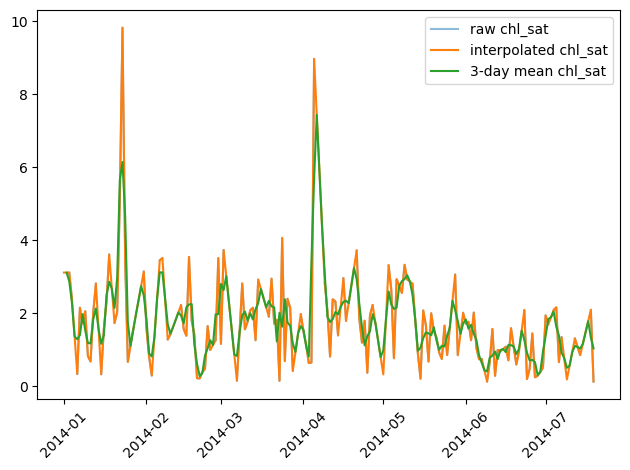

In [12]:
import matplotlib.pyplot as plt

sample = df_full.iloc[:200]   # view first 200 days

plt.figure()
plt.plot(sample['date'], sample['chl_sat'], label='raw chl_sat', alpha=0.5)
plt.plot(sample['date'], sample['chl_sat_interp'], label='interpolated chl_sat')
plt.plot(sample['date'], sample['chl_sat_3dmean'], label='3-day mean chl_sat')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
target_col = 'chl_sat_3dmean'

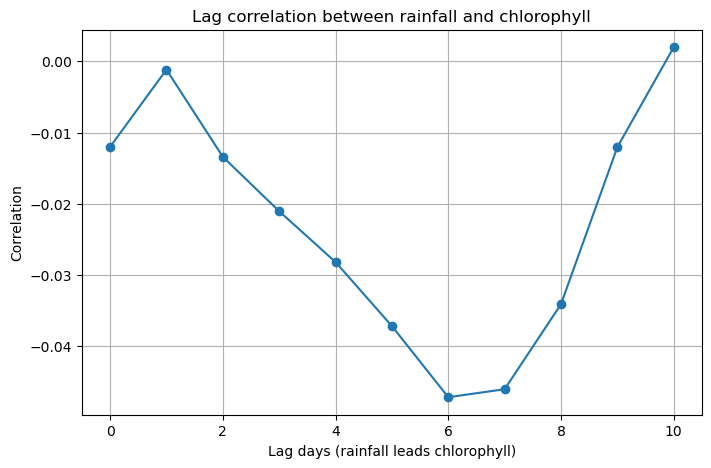

[np.float64(-0.012015121242643754),
 np.float64(-0.0011661250806031598),
 np.float64(-0.013406605349241207),
 np.float64(-0.021053462007446757),
 np.float64(-0.028185363353251065),
 np.float64(-0.03717009726414036),
 np.float64(-0.04716111775662698),
 np.float64(-0.046032679315989714),
 np.float64(-0.0341010506844559),
 np.float64(-0.012051823395824673),
 np.float64(0.0019763440866424837)]

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# target and predictor
chl = df_full['chl_sat_3dmean']
rain = df_full['P']

max_lag = 10
correlations = []

# compute correlation for lag 0 to lag 10
for lag in range(max_lag + 1):
    chl_shifted = chl.shift(-lag)  # rainfall leads chlorophyll
    corr = rain.corr(chl_shifted)
    correlations.append(corr)

# plot lag correlations
plt.figure(figsize=(8,5))
plt.plot(range(max_lag + 1), correlations, marker='o')
plt.xlabel("Lag days (rainfall leads chlorophyll)")
plt.ylabel("Correlation")
plt.title("Lag correlation between rainfall and chlorophyll")
plt.grid(True)
plt.show()

correlations

Random Forest R²: 0.0369456104064142
RMSE: 1.6082461720548955


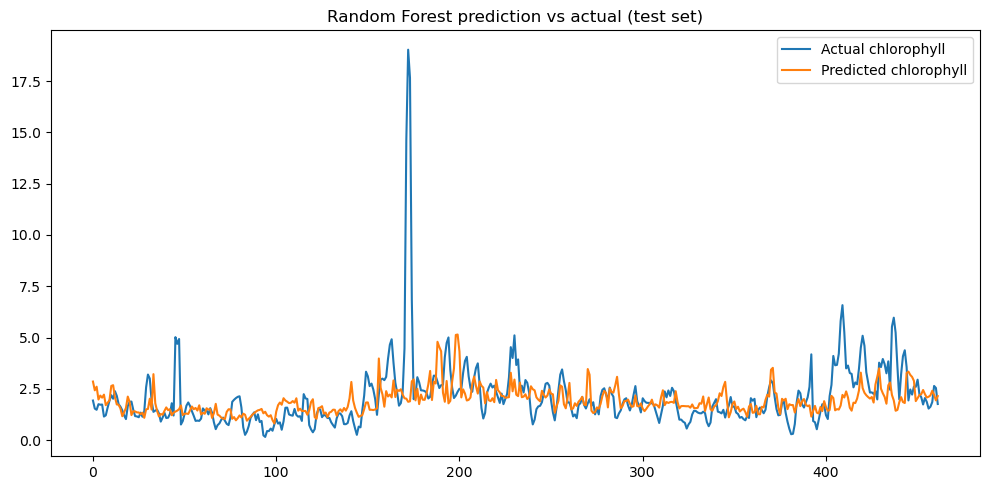

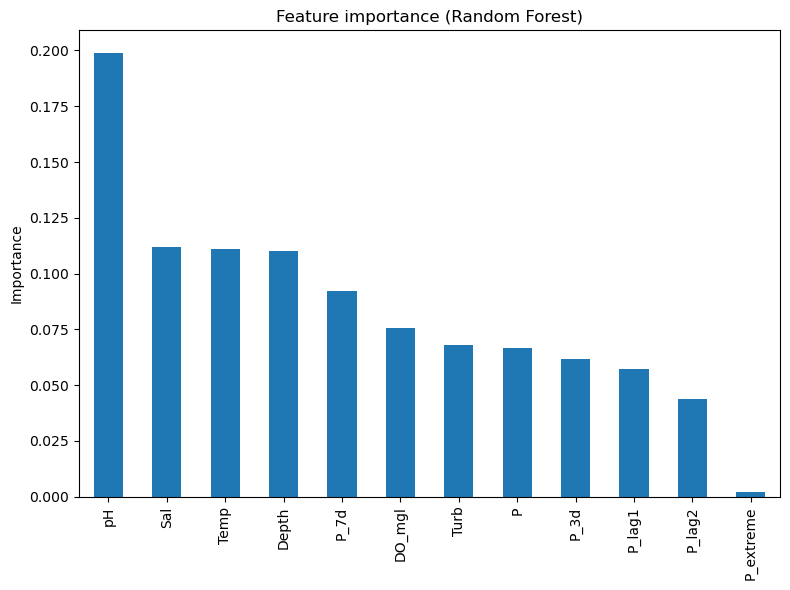

pH           0.199044
Sal          0.112119
Temp         0.111143
Depth        0.110262
P_7d         0.092341
DO_mgl       0.075526
Turb         0.068003
P            0.066677
P_3d         0.061691
P_lag1       0.057077
P_lag2       0.043894
P_extreme    0.002225
dtype: float64

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Select features and target
# -------------------------

feature_cols = [
    'P', 'P_lag1', 'P_lag2', 'P_3d', 'P_7d', 'P_extreme',
    'Temp', 'Sal', 'DO_mgl', 'Turb', 'Depth', 'pH'
]

target_col = 'chl_sat_3dmean'

df_model = df_full.dropna(subset=feature_cols + [target_col])

X = df_model[feature_cols]
y = df_model[target_col]

# -------------------------
# 2. Train-test split (70/30)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, shuffle=False
)

# -------------------------
# 3. Random Forest model
# -------------------------
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# -------------------------
# 4. Evaluate performance
# -------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest R²:", r2)
print("RMSE:", rmse)

# -------------------------
# 5. Plot predicted vs actual
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual chlorophyll')
plt.plot(y_pred, label='Predicted chlorophyll')
plt.legend()
plt.title("Random Forest prediction vs actual (test set)")
plt.tight_layout()
plt.show()

# -------------------------
# 6. Feature importance
# -------------------------
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='bar')
plt.title("Feature importance (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

importances

Linear Regression R²: -0.01839251510914175

Coefficients:
P            0.004338
P_lag1       0.001941
P_lag2      -0.007185
P_3d        -0.000906
P_7d         0.000964
P_extreme   -0.136714
Temp        -0.009259
Sal         -0.015929
DO_mgl       0.088818
Turb        -0.007484
Depth        1.092384
pH           0.689075
dtype: float64


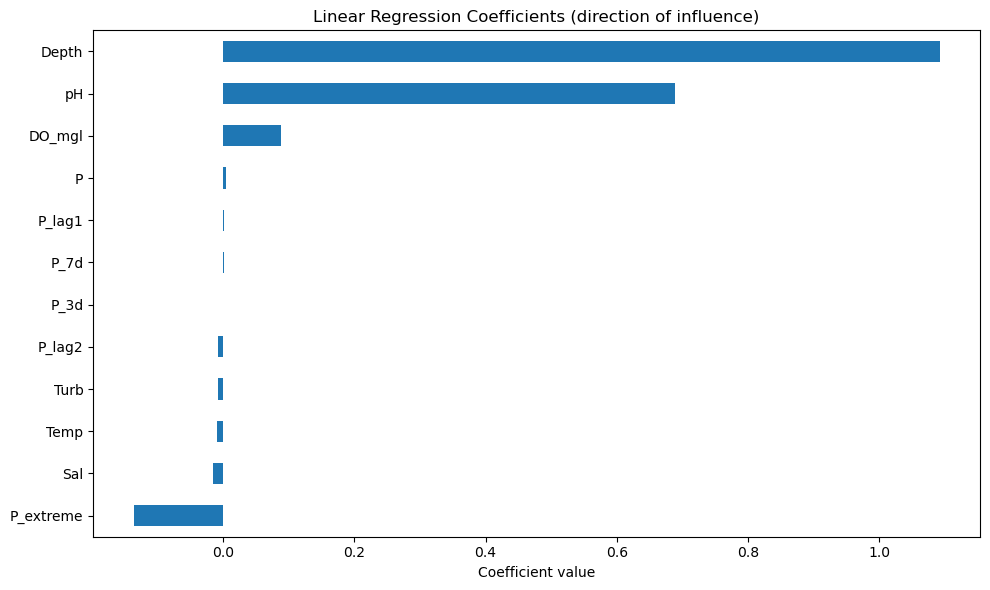

P            0.004338
P_lag1       0.001941
P_lag2      -0.007185
P_3d        -0.000906
P_7d         0.000964
P_extreme   -0.136714
Temp        -0.009259
Sal         -0.015929
DO_mgl       0.088818
Turb        -0.007484
Depth        1.092384
pH           0.689075
dtype: float64

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Select features and target
# -------------------------

feature_cols = [
    'P', 'P_lag1', 'P_lag2', 'P_3d', 'P_7d', 'P_extreme',
    'Temp', 'Sal', 'DO_mgl', 'Turb', 'Depth', 'pH'
]

target_col = 'chl_sat_3dmean'

df_model = df_full.dropna(subset=feature_cols + [target_col])

X = df_model[feature_cols]
y = df_model[target_col]

# -------------------------
# 2. Train-test split (same as RF)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, shuffle=False
)

# -------------------------
# 3. Fit Linear Regression
# -------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# -------------------------
# 4. Evaluate
# -------------------------
r2 = r2_score(y_test, y_pred)
print("Linear Regression R²:", r2)

# -------------------------
# 5. Coefficients
# -------------------------
coeffs = pd.Series(lr.coef_, index=feature_cols)
print("\nCoefficients:")
print(coeffs)

# -------------------------
# 6. Plot coefficient bar plot
# -------------------------
plt.figure(figsize=(10,6))
coeffs.sort_values().plot(kind='barh')
plt.title("Linear Regression Coefficients (direction of influence)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()

coeffs